In [37]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import *

import matplotlib.pyplot as plt
import seaborn as sns
import glob
import calendar

In [4]:
flist = glob.glob('/kaggle/input/bike-sharing-datasets/*.csv')

In [7]:
df = pd.DataFrame()

for f in flist:
    if 'divvy' in f:
        temp = pd.read_csv(f)
        df = pd.concat([df,temp],axis =0)

In [8]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,E1E065E7ED285C02,classic_bike,2022-02-19 18:08:41,2022-02-19 18:23:56,State St & Randolph St,TA1305000029,Clark St & Lincoln Ave,13179,41.884621,-87.627834,41.915689,-87.634600,member
1,1602DCDC5B30FFE3,classic_bike,2022-02-20 17:41:30,2022-02-20 17:45:56,Halsted St & Wrightwood Ave,TA1309000061,Southport Ave & Wrightwood Ave,TA1307000113,41.929143,-87.649077,41.928773,-87.663913,member
2,BE7DD2AF4B55C4AF,classic_bike,2022-02-25 18:55:56,2022-02-25 19:09:34,State St & Randolph St,TA1305000029,Canal St & Adams St,13011,41.884621,-87.627834,41.879255,-87.639904,member
3,A1789BDF844412BE,classic_bike,2022-02-14 11:57:03,2022-02-14 12:04:00,Southport Ave & Waveland Ave,13235,Broadway & Sheridan Rd,13323,41.948150,-87.663940,41.952833,-87.649993,member
4,07DE78092C62F7B3,classic_bike,2022-02-16 05:36:06,2022-02-16 05:39:00,State St & Randolph St,TA1305000029,Franklin St & Lake St,TA1307000111,41.884621,-87.627834,41.885837,-87.635500,member


In [10]:
df['started_at'] = pd.to_datetime(df['started_at'])

In [13]:
df['started_at'] = df['started_at'].dt.date

In [14]:
df['start_station_name'].nunique()

1674

In [16]:
station_demand = pd.DataFrame(df['start_station_name'].value_counts())

In [20]:
df2 = df.groupby(['started_at','rideable_type','start_station_name','member_casual']).ride_id.count()

In [21]:
df2.head()

started_at  rideable_type  start_station_name          member_casual
2022-01-01  classic_bike   900 W Harrison St           member           4
                           Aberdeen St & Jackson Blvd  member           2
                           Aberdeen St & Monroe St     member           4
                           Aberdeen St & Randolph St   member           1
                           Ada St & Washington Blvd    casual           1
Name: ride_id, dtype: int64

In [22]:
df2 = df2.reset_index()

In [23]:
df2.head()

,started_at,rideable_type,start_station_name,member_casual,ride_id
0,2022-01-01,classic_bike,900 W Harrison St,member,4
1,2022-01-01,classic_bike,Aberdeen St & Jackson Blvd,member,2
2,2022-01-01,classic_bike,Aberdeen St & Monroe St,member,4
3,2022-01-01,classic_bike,Aberdeen St & Randolph St,member,1
4,2022-01-01,classic_bike,Ada St & Washington Blvd,casual,1


<Axes: xlabel='started_at', ylabel='ride_id'>

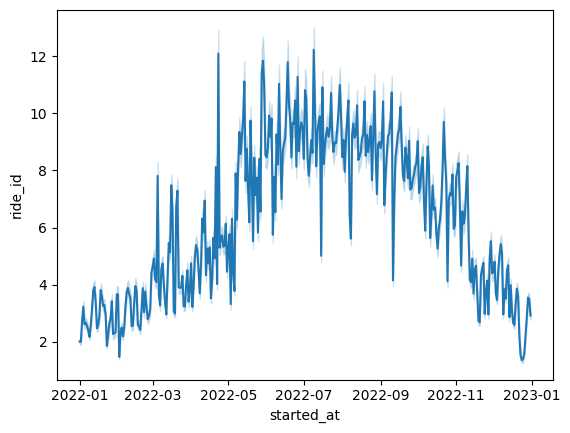

In [24]:
sns.lineplot(x='started_at',y='ride_id',data=df2)

In [26]:
df2['started_at'] = pd.to_datetime(df2['started_at'])

In [34]:
df2['day'] = df2['started_at'].apply(lambda x : x.weekday())
df2['month'] = df2['started_at'].dt.month

In [54]:
df2['day'].min()

0

In [62]:
dayname = dict(enumerate(calendar.day_name))

In [63]:
dayname

{0: 'Monday',
 1: 'Tuesday',
 2: 'Wednesday',
 3: 'Thursday',
 4: 'Friday',
 5: 'Saturday',
 6: 'Sunday'}

In [57]:
month_name = dict(enumerate(list(calendar.month_name)))

In [58]:
month_name

{0: '',
 1: 'January',
 2: 'February',
 3: 'March',
 4: 'April',
 5: 'May',
 6: 'June',
 7: 'July',
 8: 'August',
 9: 'September',
 10: 'October',
 11: 'November',
 12: 'December'}

In [67]:
df2['day'] = df2['day'].apply(lambda x : dayname[x])

In [68]:
df2['month'] = df2['month'].apply(lambda x : month_name[x])

<Axes: xlabel='day', ylabel='ride_id'>

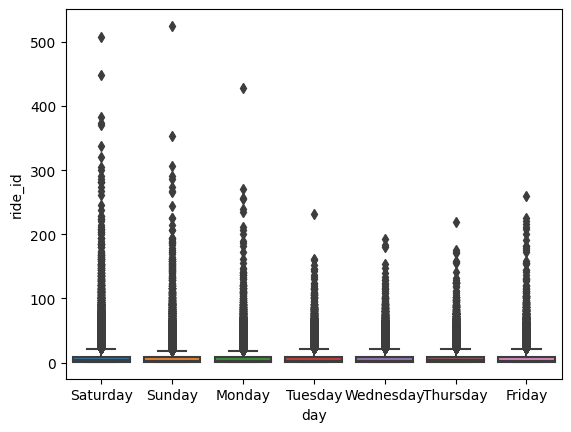

In [70]:
sns.boxplot(x='day',y='ride_id',data=df2)

<Axes: xlabel='month', ylabel='ride_id'>

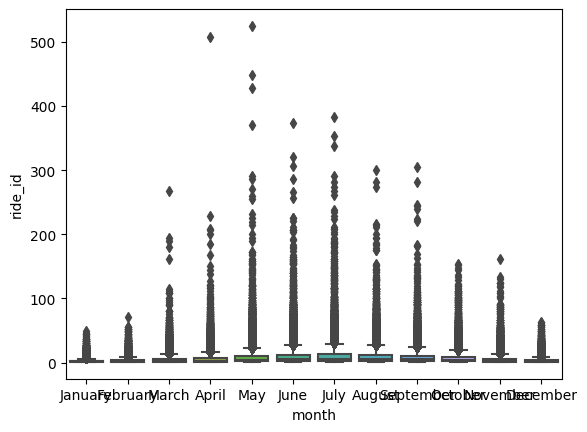

In [71]:
sns.boxplot(x='month',y='ride_id',data=df2)

In [73]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')

In [76]:
pos = df[['start_station_name','start_lat', 'start_lng']]
pos = pos.round(2)

In [78]:
pos = pos.dropna()

In [80]:
pos = pos.drop_duplicates('start_station_name')

In [81]:
pos.shape

(1674, 3)

In [83]:
df2.isnull().sum()

started_at            0
rideable_type         0
start_station_name    0
member_casual         0
ride_id               0
day                   0
month                 0
dtype: int64

In [85]:
df2 = pd.merge(df2,pos,on=['start_station_name'])

In [86]:
df2.isnull().sum()

started_at            0
rideable_type         0
start_station_name    0
member_casual         0
ride_id               0
day                   0
month                 0
start_lat             0
start_lng             0
dtype: int64

In [87]:
df2['start_lat'] = df2['start_lat'].apply(np.radians)
df2['start_lng'] = df2['start_lng'].apply(np.radians)

In [93]:
data = df2.drop(['started_at','start_station_name'],axis=1)

In [95]:
data.columns

Index(['rideable_type', 'member_casual', 'ride_id', 'day', 'month',
       'start_lat', 'start_lng'],
      dtype='object')

In [97]:
data = data.groupby(['rideable_type', 'member_casual', 'day', 'month',
       'start_lat', 'start_lng']).ride_id.mean()

In [101]:
data = data.reset_index()

In [102]:
data = pd.get_dummies(data)

In [103]:
data

,start_lat,start_lng,ride_id,rideable_type_classic_bike,rideable_type_docked_bike,rideable_type_electric_bike,member_casual_casual,member_casual_member,day_Friday,day_Monday,...,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,0.727104,-1.528908,1.000000,True,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0.727628,-1.529607,1.000000,True,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0.727802,-1.528908,1.000000,True,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,0.727977,-1.529607,1.000000,True,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,0.727977,-1.527687,1.000000,True,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99818,0.733911,-1.530130,4.000000,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
99819,0.734085,-1.531003,2.000000,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
99820,0.734085,-1.530654,2.666667,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
99821,0.734085,-1.530479,2.000000,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [104]:
x = data.drop('ride_id',axis=1)
y = data.ride_id

In [105]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)

In [106]:
model = RandomForestRegressor(max_depth = 10,n_estimators=200)
model.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=200)

In [107]:
trainPred = model.predict(x_train)
testPred = model.predict(x_test)

In [108]:
r2_score(y_train,trainPred)

0.7887757719119879

In [109]:
r2_score(y_test,testPred)

0.7475088253539353

In [112]:
import optuna

In [116]:
# 1. Define an objective function to be maximized.
def objective(trial):

    # 2. Suggest values for the hyperparameters using a trial object.
    reg_name = trial.suggest_categorical('regressor', ['LR', 'KNN','DT','RF'])
    
    if reg_name == 'LR':
        model = LinearRegression()
    elif reg_name == 'KNN':
        knn_neg = trial.suggest_int('knn_neg', 3, 23)
        model = KNeighborsRegressor(n_neighbors = knn_neg)
    elif reg_name == 'DT':
        dt_max_depth = trial.suggest_int('dt_max_depth', 2, 32, log=True)
        model = DecisionTreeRegressor(max_depth=dt_max_depth)
    elif reg_name == 'RF':
        rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32, log=True)
        rf_estimators = trial.suggest_int('rf_n_estimators',10,1000)
        model = RandomForestRegressor(max_depth=rf_max_depth, n_estimators=rf_estimators)
    
    score = cross_val_score(estimator=model,X=x_train,y=y_train,scoring='r2')
    return np.mean(score)

# 3. Create a study object and optimize the objective function.
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2023-11-26 05:54:38,199] A new study created in memory with name: no-name-12952525-461f-4c90-aa37-aacd4b646a73
[I 2023-11-26 05:54:39,282] Trial 0 finished with value: 0.008895043198637764 and parameters: {'regressor': 'LR'}. Best is trial 0 with value: 0.008895043198637764.
[I 2023-11-26 05:54:40,327] Trial 1 finished with value: 0.008895043198637764 and parameters: {'regressor': 'LR'}. Best is trial 0 with value: 0.008895043198637764.
[I 2023-11-26 05:54:54,268] Trial 2 finished with value: 0.630962543294671 and parameters: {'regressor': 'KNN', 'knn_neg': 11}. Best is trial 2 with value: 0.630962543294671.
[I 2023-11-26 05:55:08,326] Trial 3 finished with value: 0.5611700159208285 and parameters: {'regressor': 'KNN', 'knn_neg': 23}. Best is trial 2 with value: 0.630962543294671.
[I 2023-11-26 05:57:17,235] Trial 4 finished with value: 0.2351644025272887 and parameters: {'regressor': 'RF', 'rf_max_depth': 2, 'rf_n_estimators': 950}. Best is trial 2 with value: 0.630962543294671.
[I

KeyboardInterrupt: 

In [117]:
study.best_params

{'regressor': 'DT', 'dt_max_depth': 18}

In [118]:
study.best_value

0.798901516816696

In [119]:
model = DecisionTreeRegressor(max_depth=18)
model.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=18)

In [120]:
trainPred = model.predict(x_train)
testPred = model.predict(x_test)

In [121]:
r2_score(y_test,testPred)

0.802410040281941

In [123]:
import pickle

In [124]:
# save the model to disk
filename = 'finalized_model.sav'
pickle.dump(model, open(filename, 'wb'))